In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import plotly.graph_objects as go

import os
# from pyfmreaderpsnex.ps_nex.loadMaps import checkMapFileNULL, remove_nan_and_get_indices, load_map_file_csv, compute_time_difference
# from pyfmreaderpsnex.ps_nex.parseTDMS import get_channel_names, parse_tdms, grab_tdms
# from pyfmreaderpsnex.plotting import smooth_derivative
# import plotly.io as pio
# import seaborn as sns
# import sys

from pyfmreader import loadfile
import pyfmreader.ps_nex.parseTDMS as psnex
from pyfmrheo.utils.force_curves import correct_tilt
from scipy.stats import linregress




pi = math.pi
 

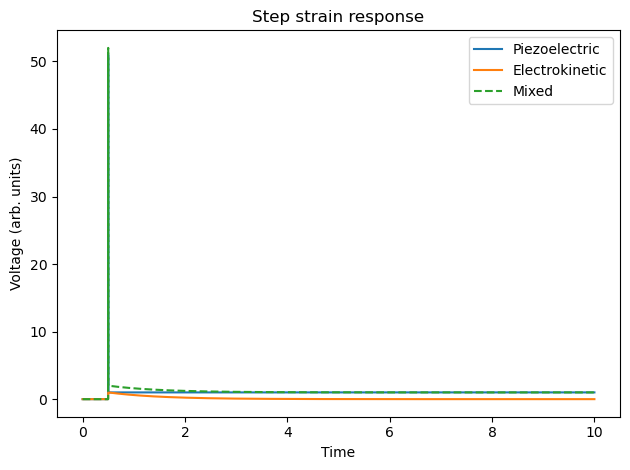

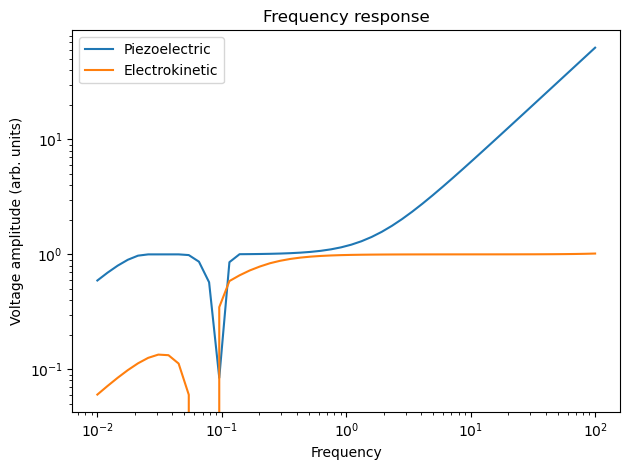

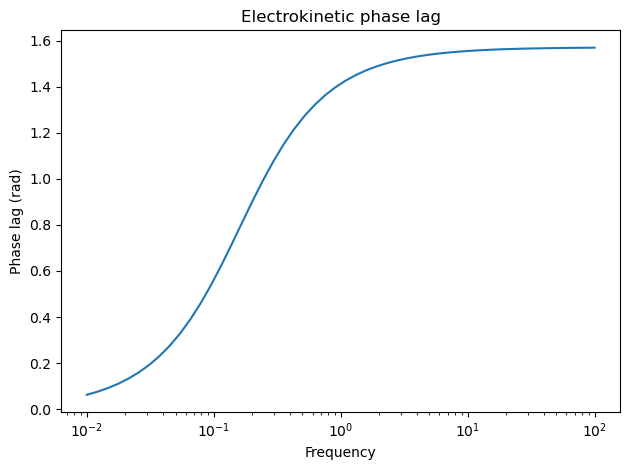

In [2]:
"""
Coupled electromechanical model for hydrated ionic gels
------------------------------------------------------

This script generates representative voltage responses for:
(a) step strain loading
(b) sinusoidal strain loading (frequency response)

The model follows Section 4 of the manuscript:
V(t) = V_p(t) + V_i(t)

where:
- V_p is the intrinsic piezoelectric contribution
- V_i is the electrokinetic (ionic) contribution

IMPORTANT:
- This code is intended for qualitative demonstration only.
- Parameters are dimensionless and chosen to illustrate trends,
  not to fit experimental data.

Authors:
Erica Pensini, Alejandro G. Marangoni

License:
MIT License (see LICENSE file)
"""

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Model parameters (dimensionless)
# -------------------------------
E = 1.0          # elastic modulus
eta = 0.1        # viscoelastic damping
d_p = 1.0        # piezoelectric coupling constant
alpha = 1.0      # electrokinetic coupling
tau = 1.0        # ionic relaxation time
C_eff = 1.0      # effective capacitance

# -------------------------------
# Time discretization
# -------------------------------
t_max = 10.0
dt = 0.001
t = np.arange(0, t_max, dt)

# -------------------------------
# Step strain protocol
# -------------------------------
epsilon_step = np.ones_like(t)
epsilon_step[t < 0.5] = 0.0

# Strain rate
epsilon_dot = np.gradient(epsilon_step, dt)

# Stress
sigma = E * epsilon_step + eta * epsilon_dot

# Piezoelectric contribution
V_p = d_p * sigma

# Ionic contribution
q = np.zeros_like(t)
for i in range(1, len(t)):
    q[i] = q[i-1] + dt * (alpha * epsilon_dot[i] - q[i-1] / tau)

V_i = q / C_eff

# -------------------------------
# Plot step response
# -------------------------------
plt.figure()
plt.plot(t, V_p, label='Piezoelectric')
plt.plot(t, V_i, label='Electrokinetic')
plt.plot(t, V_p + V_i, '--', label='Mixed')
plt.xlabel('Time')
plt.ylabel('Voltage (arb. units)')
plt.legend()
plt.title('Step strain response')
plt.tight_layout()
plt.show()

# -------------------------------
# Frequency response
# -------------------------------
frequencies = np.logspace(-2, 2, 50)
amp_p = []
amp_i = []
phase_i = []

for f in frequencies:
    omega = 2 * np.pi * f
    eps = np.sin(omega * t)
    eps_dot = omega * np.cos(omega * t)
    
    sigma = E * eps + eta * eps_dot
    Vp = d_p * sigma
    
    q = np.zeros_like(t)
    for i in range(1, len(t)):
        q[i] = q[i-1] + dt * (alpha * eps_dot[i] - q[i-1] / tau)
    Vi = q / C_eff
    
    # Amplitudes (steady-state)
    amp_p.append(np.max(Vp[int(len(t)/2):]))
    amp_i.append(np.max(Vi[int(len(t)/2):]))
    
    # Phase lag (approximate analytic form)
    phase_i.append(np.arctan(omega * tau))

# -------------------------------
# Plot frequency response
# -------------------------------
plt.figure()
plt.loglog(frequencies, amp_p, label='Piezoelectric')
plt.loglog(frequencies, amp_i, label='Electrokinetic')
plt.xlabel('Frequency')
plt.ylabel('Voltage amplitude (arb. units)')
plt.legend()
plt.title('Frequency response')
plt.tight_layout()
plt.show()

plt.figure()
plt.semilogx(frequencies, phase_i)
plt.xlabel('Frequency')
plt.ylabel('Phase lag (rad)')
plt.title('Electrokinetic phase lag')
plt.tight_layout()
plt.show()
